**New dependency:** this pipeline now uses scipy.ndimage for the texture/fallback logic. If you don't have it, run: pip install scipy


In [1]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

# Load SAM model
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

sam = sam_model_registry["vit_b"](checkpoint=r"..\checkpoints\sam_vit_b.pth")
sam.to(device=device)
print("SAM loaded successfully")

Using device: cuda


c:\Users\samee\AppData\Local\Programs\Python\Python312\Lib\site-packages\segment_anything\build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.

SAM loaded successfully


Image shape: (1173, 948, 3)


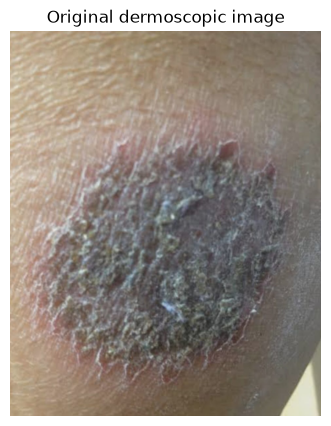

In [2]:
import os

# Pick any image from HAM10000
test_image_path = r"..\data\raw\HAM10000_images_part_1\ISIC_0024306.jpeg"
# If that doesn't exist, list available images and pick one:
if not os.path.exists(test_image_path):
    files = os.listdir(r"..\data\raw\HAM10000_images_part_1")
    print("First 5 files:", files[:5])

image = np.array(Image.open(test_image_path).convert("RGB"))
print("Image shape:", image.shape)    # (450, 600, 3) — original HAM10000 size

plt.figure(figsize=(8, 5))
plt.imshow(image)
plt.title("Original dermoscopic image")
plt.axis('off')
plt.show()

## Why dark-skin lesions were failing

SAM's automatic mask generator has no idea what a "lesion" is — it just groups
pixels using low-level colour/edge contrast. On light skin, a brown/black
lesion stands out sharply from the surrounding skin in raw RGB, so SAM finds
a clean segment. On dark skin, the lesion-vs-skin contrast in raw RGB is much
smaller, so SAM either merges the lesion into the background-skin mask (which
then gets rejected as "too large") or never proposes a distinct segment at
all — and `get_lesion_mask` falls back to using the whole image.

The old pipeline also ran **CLAHE after SAM**, purely for the classifier's
benefit. That's too late — SAM already made its (bad) segmentation decision
on the low-contrast raw image.

Two changes fix this:
1. **Run CLAHE before SAM**, with a clip limit that adapts to the image's
   own brightness (dark images get pulled harder).
2. **Score candidate masks by colour contrast against the surrounding skin**,
   not just by size/position — this is relative, so it works the same way
   regardless of whether the skin itself is light or dark. A colour-distance
   fallback replaces the "use whole image" bail-out when SAM still can't
   find a good segment.


Mean L (brightness): 134.4 / 255
Adaptive clip limit used: 2.21


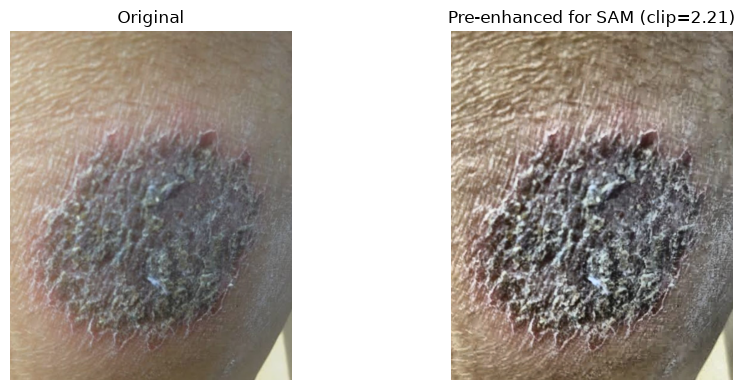

In [3]:
import cv2

def adaptive_clahe(image_rgb, base_clip=2.0, tile_grid=(8, 8)):
    """
    CLAHE with a clip limit that scales with the image's own brightness.
    Darker-skin images (lower mean L) get a stronger clip limit so the
    lesion boundary — which has lower absolute contrast on dark skin —
    still gets pulled out. Lighter images keep a gentle clip limit so we
    don't over-enhance and introduce noise.
    """
    lab = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)
    l_channel = lab[:, :, 0]
    mean_l = float(l_channel.mean())  # 0-255, lower = darker skin tone

    # mean_l ~200+ (very light skin)  -> factor ~0   -> clip ~= base_clip
    # mean_l ~60-90 (dark skin)       -> factor ~0.6-1 -> clip up to ~2x base_clip
    brightness_factor = np.clip((150.0 - mean_l) / 150.0, 0.0, 1.0)
    clip_limit = base_clip * (1.0 + brightness_factor)

    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    lab[:, :, 0] = clahe.apply(l_channel)
    enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return enhanced, clip_limit, mean_l

# Pre-enhance BEFORE segmentation (this is the key change) -----------------
sam_input_image, used_clip_limit, mean_brightness = adaptive_clahe(image)

print(f"Mean L (brightness): {mean_brightness:.1f} / 255")
print(f"Adaptive clip limit used: {used_clip_limit:.2f}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sam_input_image)
plt.title(f"Pre-enhanced for SAM (clip={used_clip_limit:.2f})")
plt.axis('off')
plt.tight_layout()
plt.show()


In [4]:
# Run SAM on the pre-enhanced image instead of the raw image.
# Everything else about the generator is unchanged.
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=16,
    pred_iou_thresh=0.88,
    stability_score_thresh=0.95,
    min_mask_region_area=500,
)

print("Running SAM on the contrast-enhanced image...")
masks = mask_generator.generate(sam_input_image)
print(f"Found {len(masks)} segments")


Running SAM on the contrast-enhanced image...
Found 4 segments


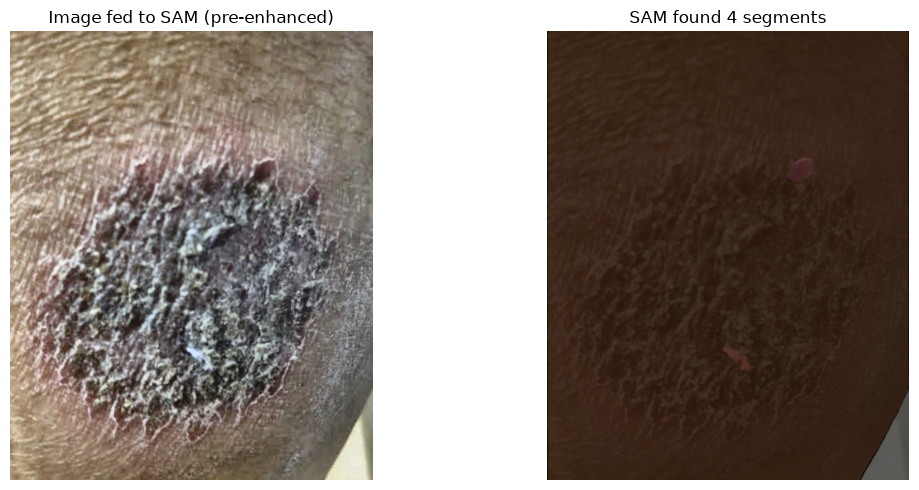

In [5]:
def show_all_masks(image, masks):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Image fed to SAM (pre-enhanced)")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(image)
    colours = plt.cm.Set1(np.linspace(0, 1, max(len(masks), 1)))
    for i, mask_data in enumerate(masks):
        mask = mask_data['segmentation']
        colour = np.array(colours[i][:3])
        coloured_mask = np.zeros_like(image, dtype=float)
        coloured_mask[mask] = colour
        plt.imshow(coloured_mask, alpha=0.4)
    plt.title(f"SAM found {len(masks)} segments")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

show_all_masks(sam_input_image, masks)


## Update: brightness alone wasn't the real signal

Testing on an actual failing image showed the problem isn't always "dark
skin = low brightness contrast." A crusty/keratotic lesion can sit on
skin with only a ~9-point difference in lightness (L), which is why the
colour-distance approach still missed it. What *did* separate it cleanly:

- **Saturation** — the lesion was noticeably less saturated (greyer) than
  the surrounding skin
- **Local texture (roughness)** — the lesion surface had roughly 2x the
  local pixel-intensity variance of normal skin

So the mask scoring below adds saturation-difference and texture-difference
terms alongside colour distance, and the fallback (used when SAM proposes
nothing usable) is rebuilt around the same combined score. This generalises
better than a pure brightness/colour approach because it isn't assuming
*which* attribute makes the lesion stand out — it checks three independent
ones and lets whichever is strongest for that image dominate.


In [6]:
from scipy import ndimage

def get_border_stats(image_rgb, border_width=15):
    """
    Reference stats from the outer ring of the image: median colour,
    median saturation, median local texture. This is the 'what does
    normal skin look like in this photo' baseline that everything else
    is compared against -- so it adapts to whatever the actual skin
    tone/lighting is, instead of using fixed absolute thresholds.
    """
    h, w = image_rgb.shape[:2]
    bw = min(border_width, h // 4, w // 4)

    hsv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV).astype(float)
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY).astype(float)
    mean_local = ndimage.uniform_filter(gray, size=9)
    sq_local = ndimage.uniform_filter(gray ** 2, size=9)
    local_texture = np.sqrt(np.maximum(sq_local - mean_local ** 2, 0))

    def border_median(channel):
        return np.median(np.concatenate([
            channel[:bw, :].ravel(), channel[-bw:, :].ravel(),
            channel[:, :bw].ravel(), channel[:, -bw:].ravel()
        ]))

    border_rgb = np.median(np.concatenate([
        image_rgb[:bw, :].reshape(-1, 3), image_rgb[-bw:, :].reshape(-1, 3),
        image_rgb[:, :bw].reshape(-1, 3), image_rgb[:, -bw:].reshape(-1, 3)
    ]), axis=0)

    return {
        "rgb": border_rgb,
        "sat": border_median(hsv[:, :, 1]),
        "texture": border_median(local_texture),
    }, hsv, local_texture


def combined_contrast_score(image_rgb):
    """
    Per-pixel score combining colour, saturation, and texture distance
    from the local skin baseline. No single one of these is reliable on
    its own across all lesion types/skin tones -- pigmented lesions on
    light skin separate mostly on colour; crusty/keratotic lesions often
    separate mostly on texture and desaturation instead. Combining them
    means the pipeline isn't betting on one cue.
    """
    stats, hsv, local_texture = get_border_stats(image_rgb)

    colour_diff = np.linalg.norm(image_rgb.astype(float) - stats["rgb"], axis=2)
    sat_diff = np.abs(hsv[:, :, 1].astype(float) - stats["sat"])
    tex_diff = np.abs(local_texture - stats["texture"])

    def norm(x):
        x = x - x.min()
        return x / (x.max() + 1e-6)

    score = 0.3 * norm(colour_diff) + 0.3 * norm(sat_diff) + 0.4 * norm(tex_diff)
    return score


def contrast_fallback(image_rgb, percentile=80):
    """
    Used when SAM proposes no usable candidate. Thresholds the combined
    colour+saturation+texture score, keeps the single largest connected
    region (so we don't return scattered noise), and cleans it up.
    """
    score = combined_contrast_score(image_rgb)
    thresh = np.percentile(score, percentile)
    raw_mask = score > thresh

    labeled, n = ndimage.label(raw_mask)
    if n == 0:
        return raw_mask
    sizes = ndimage.sum(raw_mask, labeled, range(1, n + 1))
    biggest = np.argmax(sizes) + 1
    mask = labeled == biggest
    mask = ndimage.binary_closing(mask, structure=np.ones((9, 9)))
    mask = ndimage.binary_fill_holes(mask)
    return mask


## Fix: a small glare/highlight speck was winning over the real lesion

Symptom you hit: the final mean-brightness reading collapsed to ~0.3 and
the "lesion mask" was a tiny blob nowhere near the visible lesion.

Root cause -- **not** a dtype/scale bug. `masked_image` sets everything
outside the picked mask to black, so if the mask is tiny, the whole-frame
brightness average is dominated by black background and means nothing.
The actual bug is one level up: the mask-scoring formula weighted *mean*
contrast per candidate too heavily. A small, uniformly bright glare spot
can average a higher contrast score than the real lesion, whose average
gets pulled down by its own more textured/uneven interior.

Three changes below:
1. Raise the minimum candidate size (a lesion should be a meaningful chunk
   of the frame, not <0.2% of it -- that threshold was letting tiny
   glare/hair/shadow blobs into contention at all).
2. Rebalance the score so area/position lead and contrast refines,
   instead of contrast dominating.
3. Print every candidate's stats so you can see exactly why one mask won
   instead of guessing -- if it picks wrong again, paste that printout
   back and we can tune from real numbers instead of another blind guess.


  score   area%   dist%  contrast
 -0.320    1.3%   44.2%     0.317


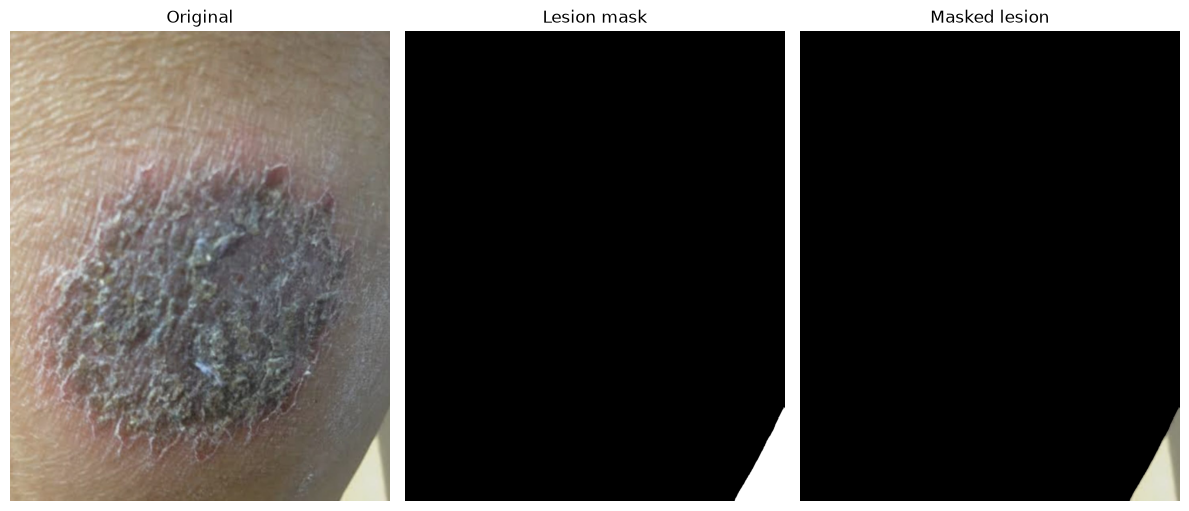

In [7]:
def get_lesion_mask(masks, image_rgb, image_shape, debug=True):
    """
    Strategy: the lesion is typically central, sizeable, does not touch
    all edges, AND stands out from the surrounding skin on colour,
    saturation, or texture. Area/position lead the score; contrast
    refines it -- a small high-contrast outlier (glare, hair, shadow)
    should not be able to outscore a large, real lesion candidate.
    """
    h, w = image_shape[:2]
    centre_y, centre_x = h // 2, w // 2
    contrast_score_map = combined_contrast_score(image_rgb)

    MIN_AREA_FRAC = 0.01   # lesion should be at least ~1% of the frame

    candidates = []
    for mask_data in masks:
        seg = mask_data['segmentation']
        area = mask_data['area']
        area_frac = area / (h * w)

        if area_frac > 0.95 or area_frac < MIN_AREA_FRAC:
            continue

        edges_touched = sum([
            np.any(seg[0, :]), np.any(seg[-1, :]),
            np.any(seg[:, 0]), np.any(seg[:, -1])
        ])
        if edges_touched >= 3:
            continue

        ys, xs = np.where(seg)
        if len(ys) == 0:
            continue
        seg_cy, seg_cx = ys.mean(), xs.mean()
        dist = ((seg_cy - centre_y) ** 2 + (seg_cx - centre_x) ** 2) ** 0.5
        max_dist = (h ** 2 + w ** 2) ** 0.5
        dist_frac = dist / max_dist

        # Median (not mean) contrast within the candidate -- robust to a
        # handful of extreme outlier pixels (glare, hair) skewing the
        # average of an otherwise unremarkable region.
        region_contrast = float(np.median(contrast_score_map[seg]))

        score = 2.0 * area_frac - 1.5 * dist_frac + 1.0 * region_contrast
        candidates.append((score, area_frac, dist_frac, region_contrast, seg))

    if debug and candidates:
        print(f"{'score':>7} {'area%':>7} {'dist%':>7} {'contrast':>9}")
        for score, area_frac, dist_frac, region_contrast, _ in sorted(candidates, key=lambda c: -c[0])[:8]:
            print(f"{score:7.3f} {area_frac*100:6.1f}% {dist_frac*100:6.1f}% {region_contrast:9.3f}")

    if not candidates:
        print("SAM gave no usable candidate -> using colour+saturation+texture fallback.")
        return contrast_fallback(image_rgb)

    best = max(candidates, key=lambda c: c[0])
    return best[4]


lesion_mask = get_lesion_mask(masks, sam_input_image, image.shape)

masked_image = image.copy()
masked_image[~lesion_mask] = 0

plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(image); plt.title("Original"); plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(lesion_mask, cmap='gray'); plt.title("Lesion mask"); plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(masked_image); plt.title("Masked lesion"); plt.axis('off')
plt.tight_layout()
plt.show()


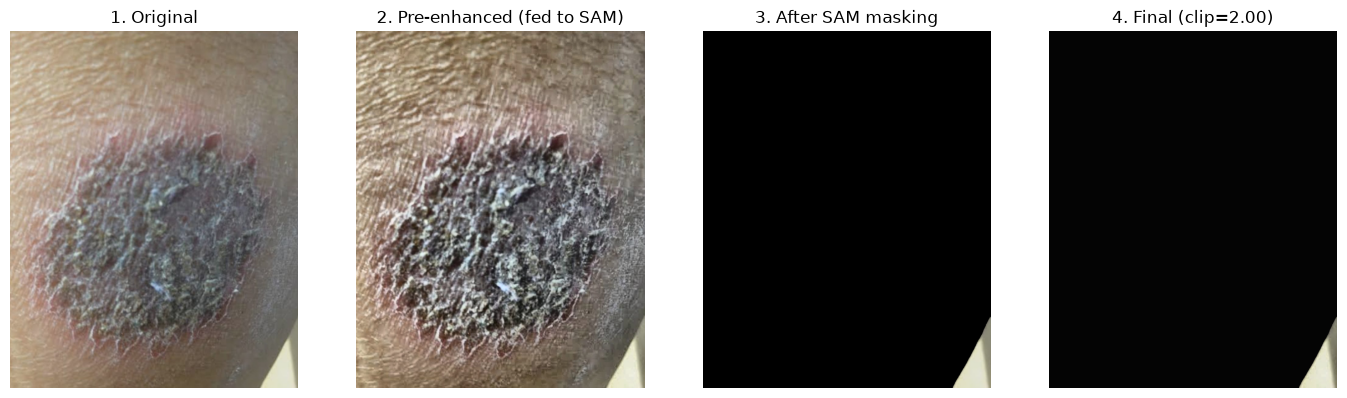

SAM + adaptive CLAHE pipeline working ✅
Final adaptive clip limit for this image: 2.00 (lesion-only mean L=200.1)
Lesion mask covers 1.31% of the frame
This is what every image will look like before going into the model


In [8]:
# Final normalisation pass on the masked lesion -- this is what actually
# goes into the model. Brightness/clip-limit is computed from the LESION
# PIXELS ONLY (not the whole frame), since the frame is mostly black
# background after masking and would otherwise swamp the statistic.
lesion_pixels = image[lesion_mask]
if lesion_pixels.size == 0:
    raise ValueError("Empty lesion mask -- nothing to enhance.")

lesion_lab = cv2.cvtColor(lesion_pixels.reshape(1, -1, 3), cv2.COLOR_RGB2LAB)
final_mean_l = float(lesion_lab[0, :, 0].mean())
final_brightness_factor = np.clip((150.0 - final_mean_l) / 150.0, 0.0, 1.0)
final_clip = 2.0 * (1.0 + final_brightness_factor)

final_image, _, _ = adaptive_clahe(masked_image, base_clip=2.0)
# override clip-limit derivation with the lesion-only estimate:
lab_full = cv2.cvtColor(masked_image, cv2.COLOR_RGB2LAB)
clahe = cv2.createCLAHE(clipLimit=final_clip, tileGridSize=(8, 8))
lab_full[:, :, 0] = clahe.apply(lab_full[:, :, 0])
final_image = cv2.cvtColor(lab_full, cv2.COLOR_LAB2RGB)

plt.figure(figsize=(14, 4))
plt.subplot(1, 4, 1)
plt.imshow(image); plt.title("1. Original"); plt.axis('off')
plt.subplot(1, 4, 2)
plt.imshow(sam_input_image); plt.title("2. Pre-enhanced (fed to SAM)"); plt.axis('off')
plt.subplot(1, 4, 3)
plt.imshow(masked_image); plt.title("3. After SAM masking"); plt.axis('off')
plt.subplot(1, 4, 4)
plt.imshow(final_image); plt.title(f"4. Final (clip={final_clip:.2f})"); plt.axis('off')
plt.tight_layout()
plt.savefig(r"sam_clahe_pipeline_v2.png")
plt.show()

print("SAM + adaptive CLAHE pipeline working \u2705")
print(f"Final adaptive clip limit for this image: {final_clip:.2f} (lesion-only mean L={final_mean_l:.1f})")
print(f"Lesion mask covers {lesion_mask.mean()*100:.2f}% of the frame")
print("This is what every image will look like before going into the model")
